# Machine Learning: Clustering Algorithms Tutorial

This notebook covers three fundamental clustering algorithms:
- **K-Means Clustering**
- **DBSCAN (Density-Based Spatial Clustering)**
- **Hierarchical Clustering**

Each section includes theory, visualizations, and practical Python code using **matplotlib** only.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings("ignore")

# Set global random seed for reproducibility
np.random.seed(42)


# 1. K-Means Clustering

## Theory

**K-Means** is a centroid-based partitioning algorithm. The goal is to partition `n` observations into `k` clusters where each observation belongs to the cluster with the nearest mean (centroid).

### Algorithm Steps:
1. **Initialize**: Choose `k` initial centroids randomly.
2. **Assign**: Assign each data point to the nearest centroid.
3. **Update**: Recalculate centroids as the mean of all points in the cluster.
4. **Repeat**: Steps 2-3 until convergence (centroids stop moving).

### Pros:
- Simple and fast (O(n * k * i * d) where i = iterations, d = dimensions)
- Works well with spherical, equally-sized clusters

### Cons:
- Requires specifying `k` in advance
- Sensitive to initial centroid placement
- Struggles with non-convex shapes and varying densities
- Sensitive to outliers

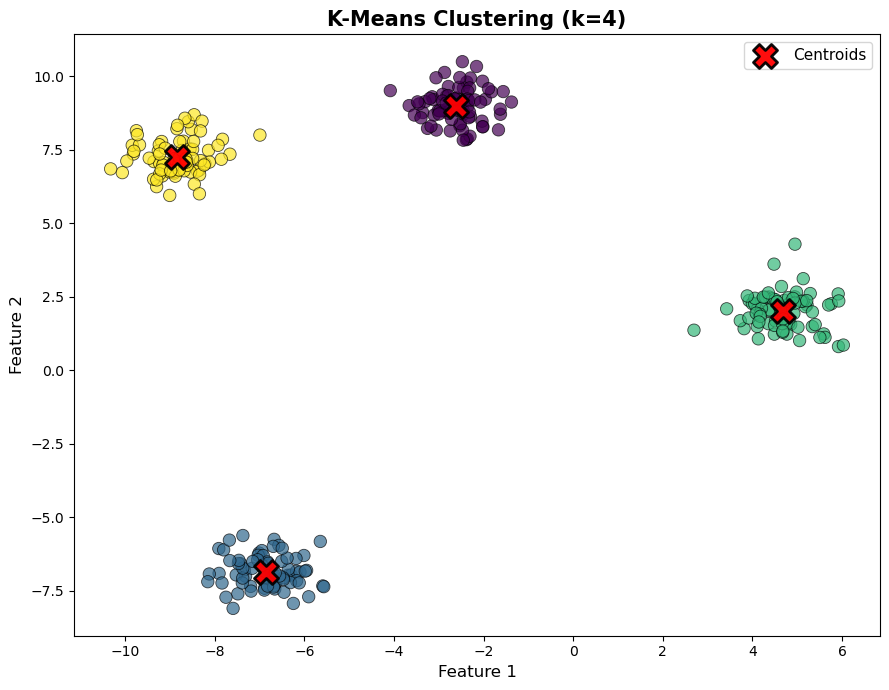

In [10]:
# Generate sample data: 4 distinct blobs
X_blobs, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)

# Apply K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_blobs)
centers = kmeans.cluster_centers_

# Visualization
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    X_blobs[:, 0], X_blobs[:, 1], 
    c=y_kmeans, cmap="viridis", s=80, 
    alpha=0.7, edgecolors="k", linewidth=0.6
)
ax.scatter(
    centers[:, 0], centers[:, 1], 
    c="red", s=300, alpha=0.95, marker="X", 
    edgecolors="black", linewidth=2, label="Centroids", zorder=5
)
ax.set_title("K-Means Clustering (k=4)", fontsize=15, fontweight="bold")
ax.set_xlabel("Feature 1", fontsize=12)
ax.set_ylabel("Feature 2", fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


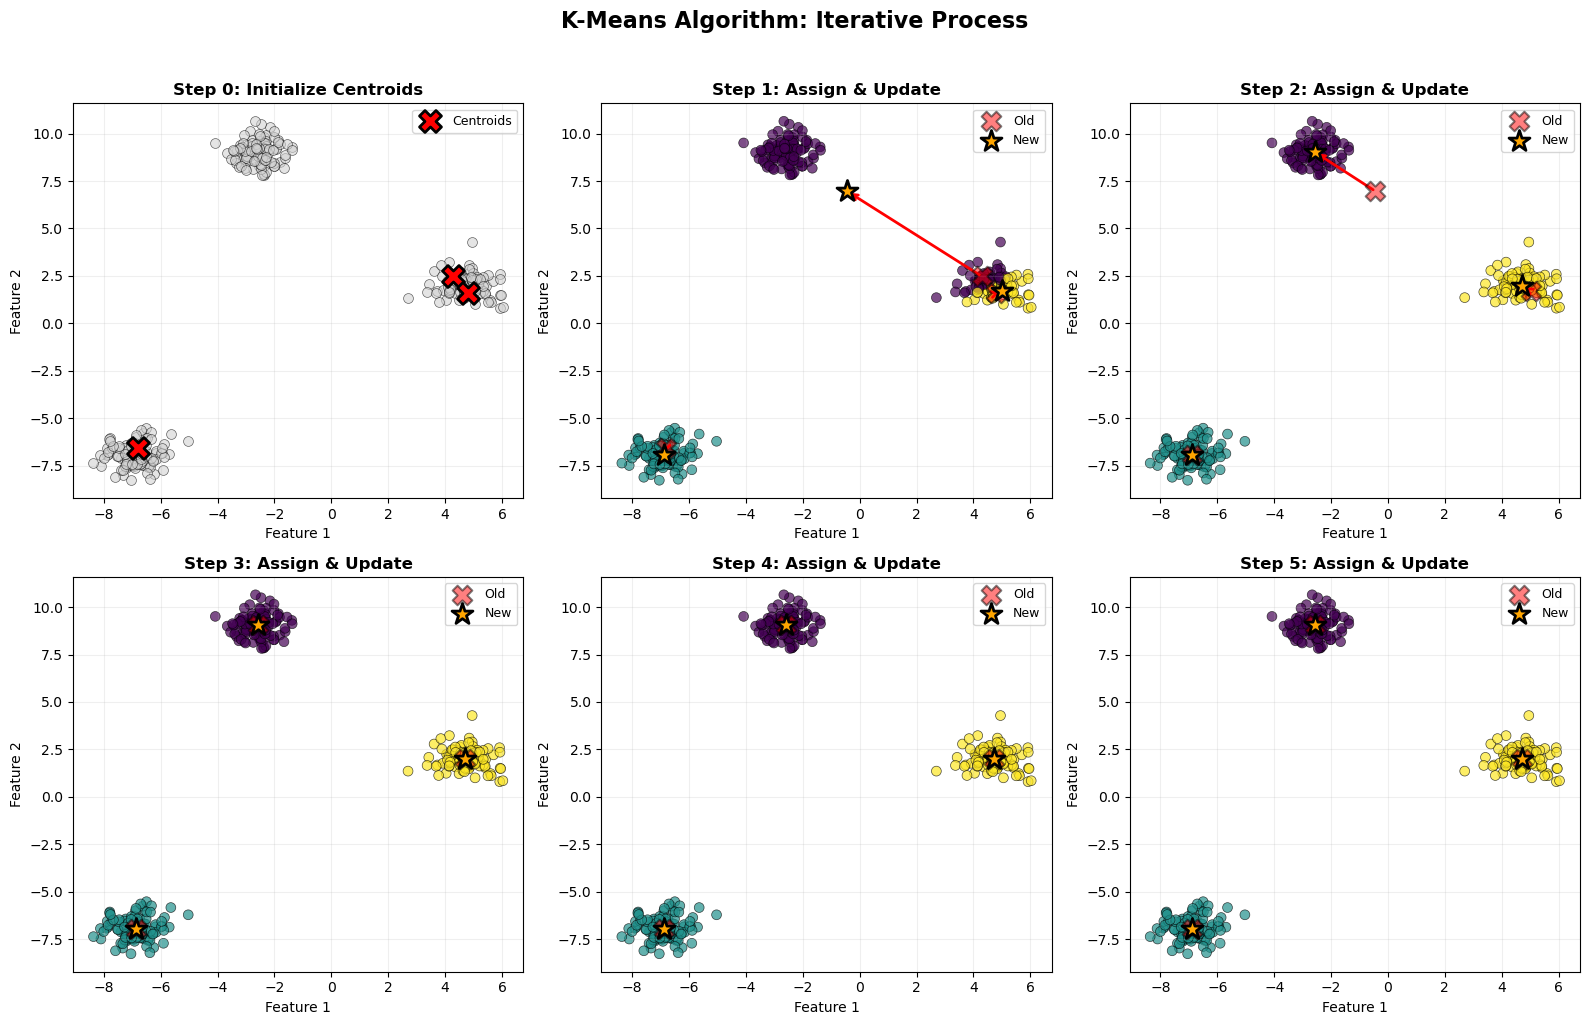

In [11]:
# K-Means Step-by-Step Visualization
X_iter, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Random initialization
np.random.seed(42)
centroids = X_iter[np.random.choice(X_iter.shape[0], 3, replace=False)]

for step in range(6):
    ax = axes[step]
    
    if step == 0:
        ax.scatter(X_iter[:, 0], X_iter[:, 1], c="lightgray", s=50, alpha=0.6, edgecolors="k", linewidth=0.5)
        ax.scatter(centroids[:, 0], centroids[:, 1], c="red", s=250, marker="X", 
                   edgecolors="black", linewidth=2, label="Centroids", zorder=5)
        ax.set_title("Step 0: Initialize Centroids", fontsize=12, fontweight="bold")
    else:
        # Assign step: compute distances to each centroid
        distances = np.sqrt(((X_iter - centroids[:, np.newaxis])**2).sum(axis=2))
        labels = np.argmin(distances, axis=0)
        
        # Plot points colored by assignment
        ax.scatter(X_iter[:, 0], X_iter[:, 1], c=labels, cmap="viridis", s=50, 
                   alpha=0.7, edgecolors="k", linewidth=0.5)
        
        # Plot old centroids
        ax.scatter(centroids[:, 0], centroids[:, 1], c="red", s=200, marker="X", 
                   edgecolors="black", linewidth=1.5, alpha=0.5, label="Old", zorder=4)
        
        # Update step: compute new centroids
        new_centroids = np.zeros_like(centroids)
        for i in range(3):
            points_in_cluster = X_iter[labels == i]
            if len(points_in_cluster) > 0:
                new_centroids[i] = points_in_cluster.mean(axis=0)
            else:
                new_centroids[i] = centroids[i]
        
        # Plot new centroids
        ax.scatter(new_centroids[:, 0], new_centroids[:, 1], c="orange", s=250, marker="*", 
                   edgecolors="black", linewidth=2, label="New", zorder=5)
        
        # Draw arrows from old to new
        for i in range(3):
            ax.annotate("", xy=new_centroids[i], xytext=centroids[i],
                       arrowprops=dict(arrowstyle="->", color="red", lw=2))
        
        ax.set_title("Step " + str(step) + ": Assign & Update", fontsize=12, fontweight="bold")
        centroids = new_centroids
    
    ax.set_xlabel("Feature 1", fontsize=10)
    ax.set_ylabel("Feature 2", fontsize=10)
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.2)

plt.suptitle("K-Means Algorithm: Iterative Process", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


# 2. Finding the Optimal Number of Clusters (k)

Since K-Means requires `k` as input, we need methods to determine the best value.

## 2.1 Elbow Method

The **Elbow Method** plots the **inertia** (within-cluster sum of squares) against different values of `k`. 
The "elbow" point where the rate of decrease sharply changes indicates a good choice for `k`.


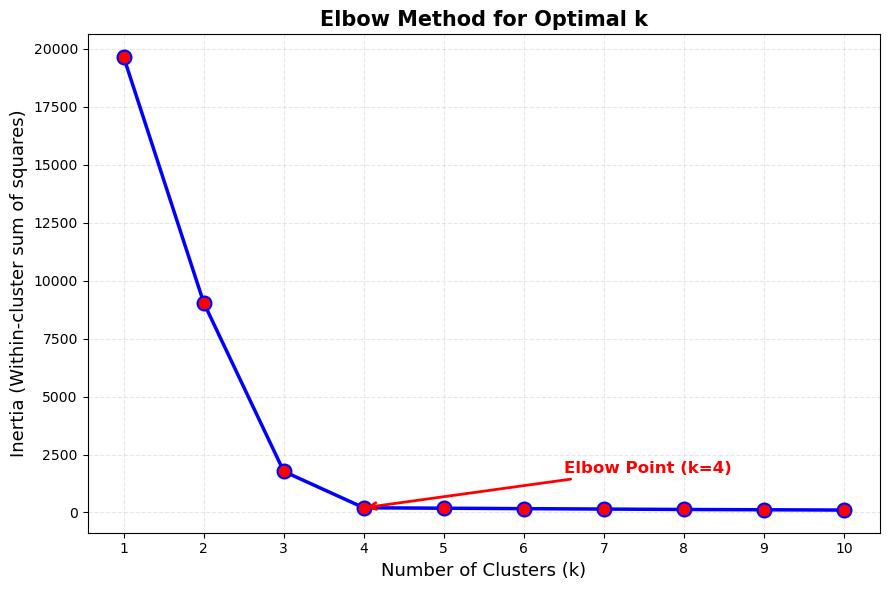

In [12]:
# Elbow Method
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_blobs)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(K_range, inertias, "bo-", markersize=10, linewidth=2.5, markerfacecolor="red", markeredgewidth=1.5)
ax.set_xlabel("Number of Clusters (k)", fontsize=13)
ax.set_ylabel("Inertia (Within-cluster sum of squares)", fontsize=13)
ax.set_title("Elbow Method for Optimal k", fontsize=15, fontweight="bold")
ax.set_xticks(list(K_range))
ax.grid(True, alpha=0.3, linestyle="--")

# Annotate the elbow
ax.annotate("Elbow Point (k=4)", xy=(4, inertias[3]), xytext=(6.5, inertias[3] + 1500),
            arrowprops=dict(arrowstyle="->", color="red", lw=2),
            fontsize=12, color="red", fontweight="bold")
plt.tight_layout()
plt.show()


## 2.2 Silhouette Analysis

The **Silhouette Coefficient** measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation).

- Range: **[-1, 1]**
- **+1**: Object is well matched to its own cluster and poorly matched to neighboring clusters
- **0**: Object is on or very close to the decision boundary between two neighboring clusters
- **-1**: Object is probably assigned to the wrong cluster

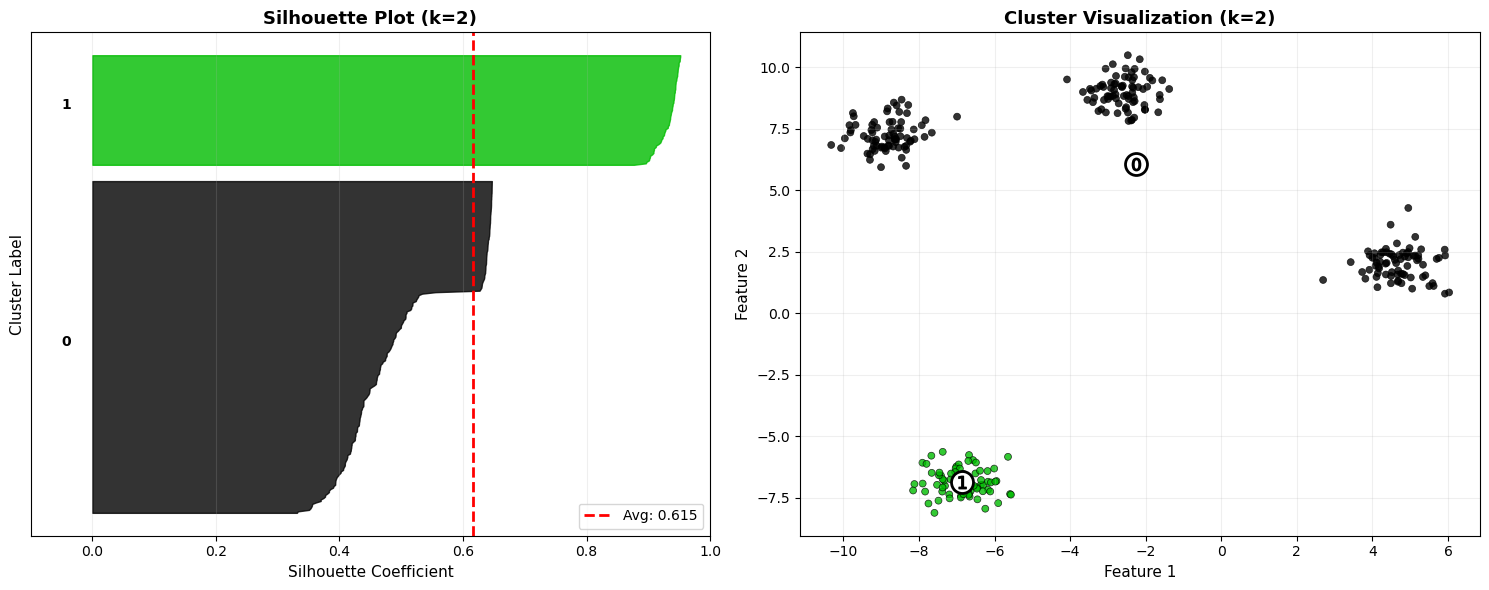

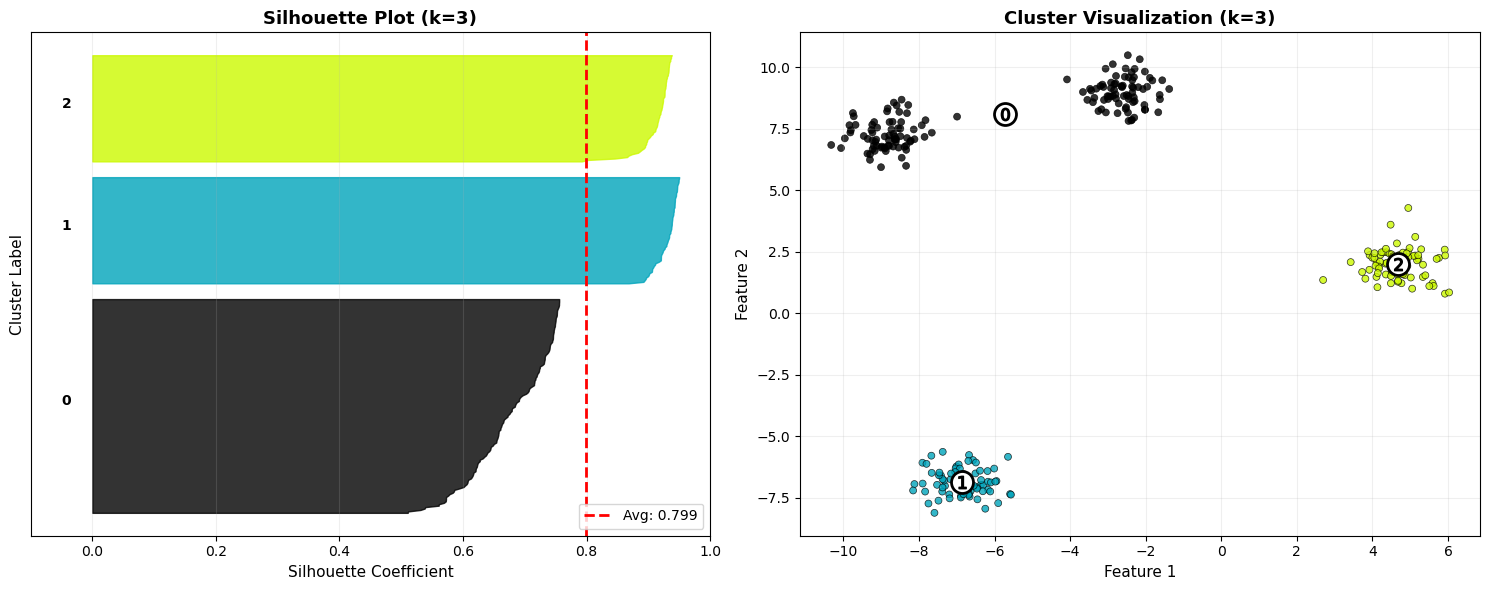

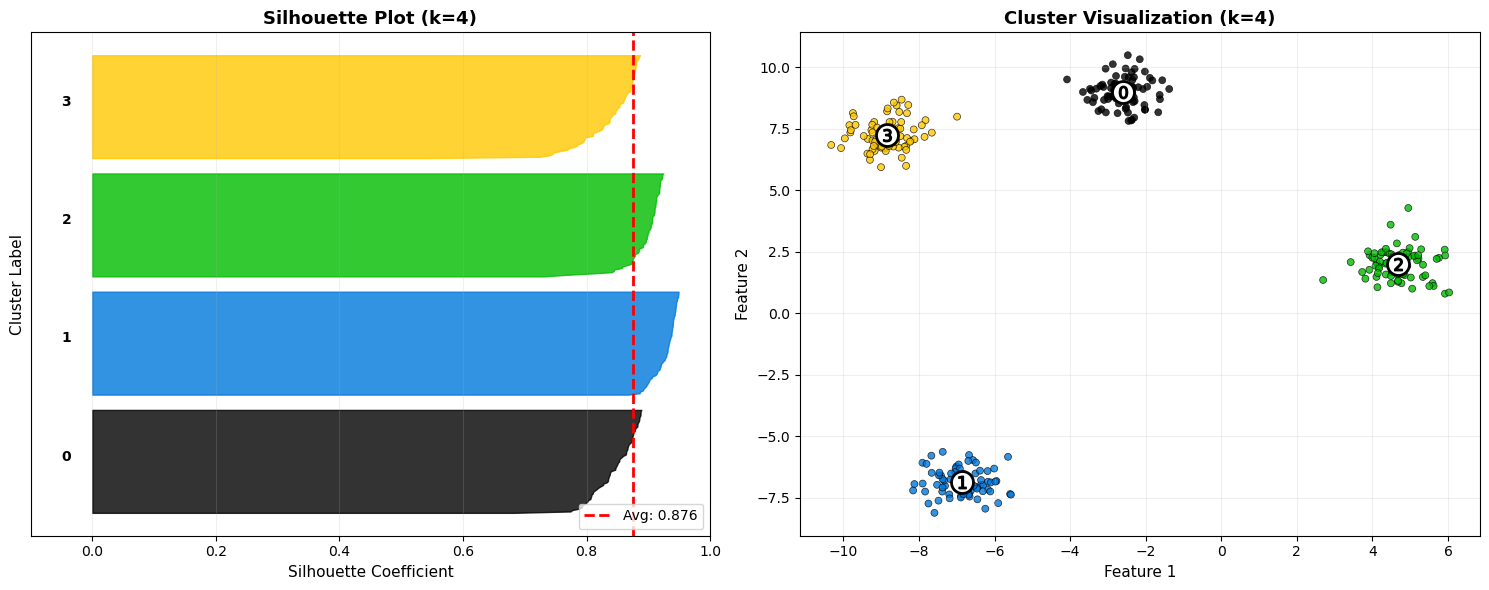

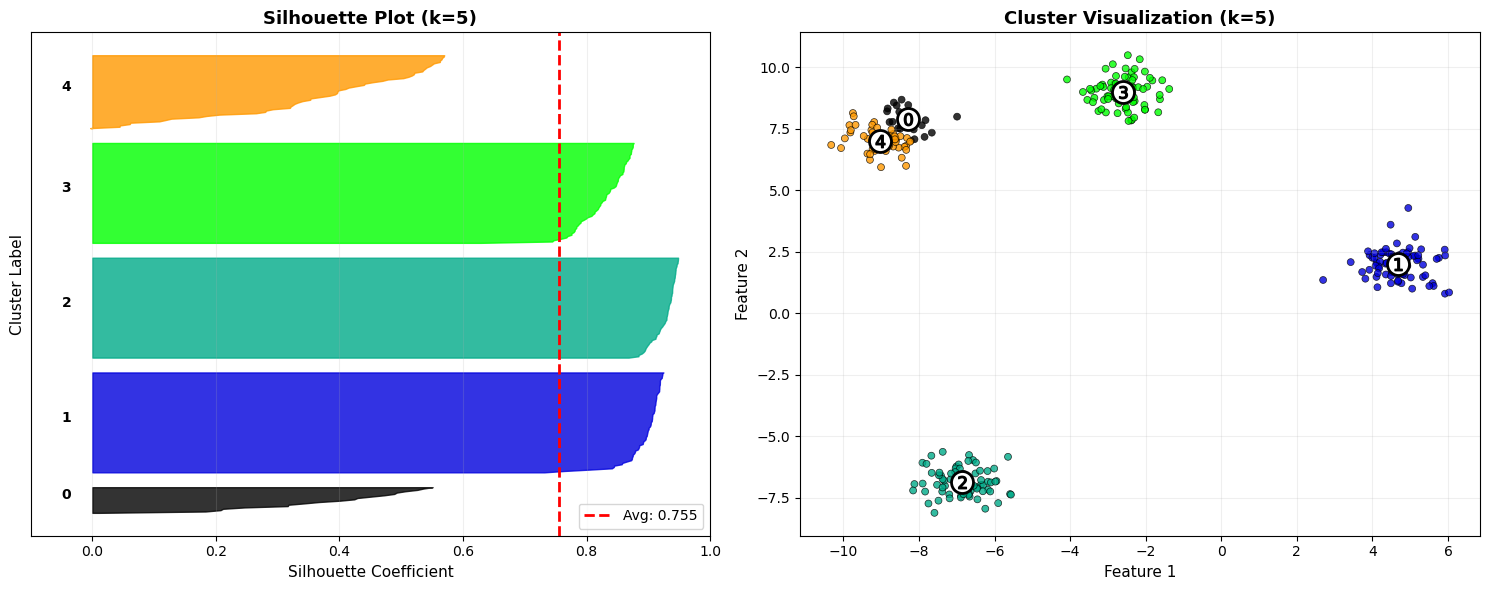

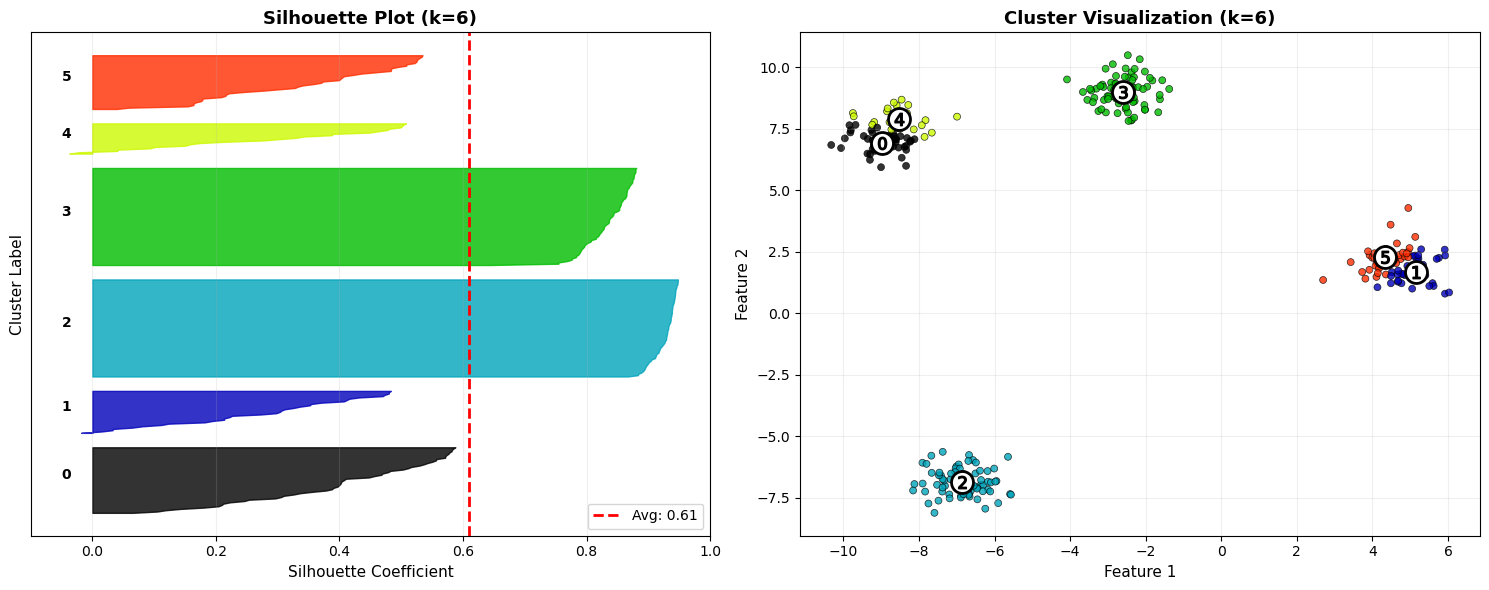

In [21]:
# Silhouette Analysis for different k values
range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = clusterer.fit_predict(X_blobs)
    
    silhouette_avg = silhouette_score(X_blobs, cluster_labels)
    sample_silhouette_values = silhouette_samples(X_blobs, cluster_labels)
    
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0, ith_cluster_silhouette_values,
            facecolor=color, edgecolor=color, alpha=0.8
        )
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=10, fontweight="bold")
        y_lower = y_upper + 10
    
    ax1.set_title("Silhouette Plot (k=" + str(n_clusters) + ")", fontsize=13, fontweight="bold")
    ax1.set_xlabel("Silhouette Coefficient", fontsize=11)
    ax1.set_ylabel("Cluster Label", fontsize=11)
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--", linewidth=2, 
                label="Avg: " + str(round(silhouette_avg, 3)))
    ax1.set_yticks([])
    ax1.set_xlim([-0.1, 1])
    ax1.legend(loc="lower right", fontsize=10)
    ax1.grid(True, alpha=0.2)
    
    # Cluster visualization
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(X_blobs[:, 0], X_blobs[:, 1], marker=".", s=100, alpha=0.8, 
                c=colors, edgecolor="k", linewidth=0.5)
    centers = clusterer.cluster_centers_
    ax2.scatter(centers[:, 0], centers[:, 1], marker="o", c="white", alpha=1, s=250, 
                edgecolor="k", linewidth=2, zorder=5)
    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$" + str(i) + "$", alpha=1, s=80, 
                    edgecolor="k", color="black", zorder=6)
    
    ax2.set_title("Cluster Visualization (k=" + str(n_clusters) + ")", fontsize=13, fontweight="bold")
    ax2.set_xlabel("Feature 1", fontsize=11)
    ax2.set_ylabel("Feature 2", fontsize=11)
    ax2.grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.show()


# 3. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

## Theory

**DBSCAN** groups together points that are closely packed together, marking points that lie alone in low-density regions as outliers (noise).

### Key Parameters:
- **eps (epsilon)**: The maximum distance between two samples for them to be considered as neighbors.
- **min_samples**: The minimum number of points required to form a dense region (core point).

### Point Types:
- **Core Point**: Has at least `min_samples` points within `eps` distance.
- **Border Point**: Within `eps` distance of a core point but does not have enough neighbors to be core.
- **Noise Point**: Neither core nor border point (labeled as -1).

### Pros:
- Does not require specifying the number of clusters
- Can find arbitrarily shaped clusters
- Robust to outliers (identifies noise)

### Cons:
- Sensitive to `eps` and `min_samples` parameters
- Struggles with varying density clusters
- Performance degrades with high-dimensional data

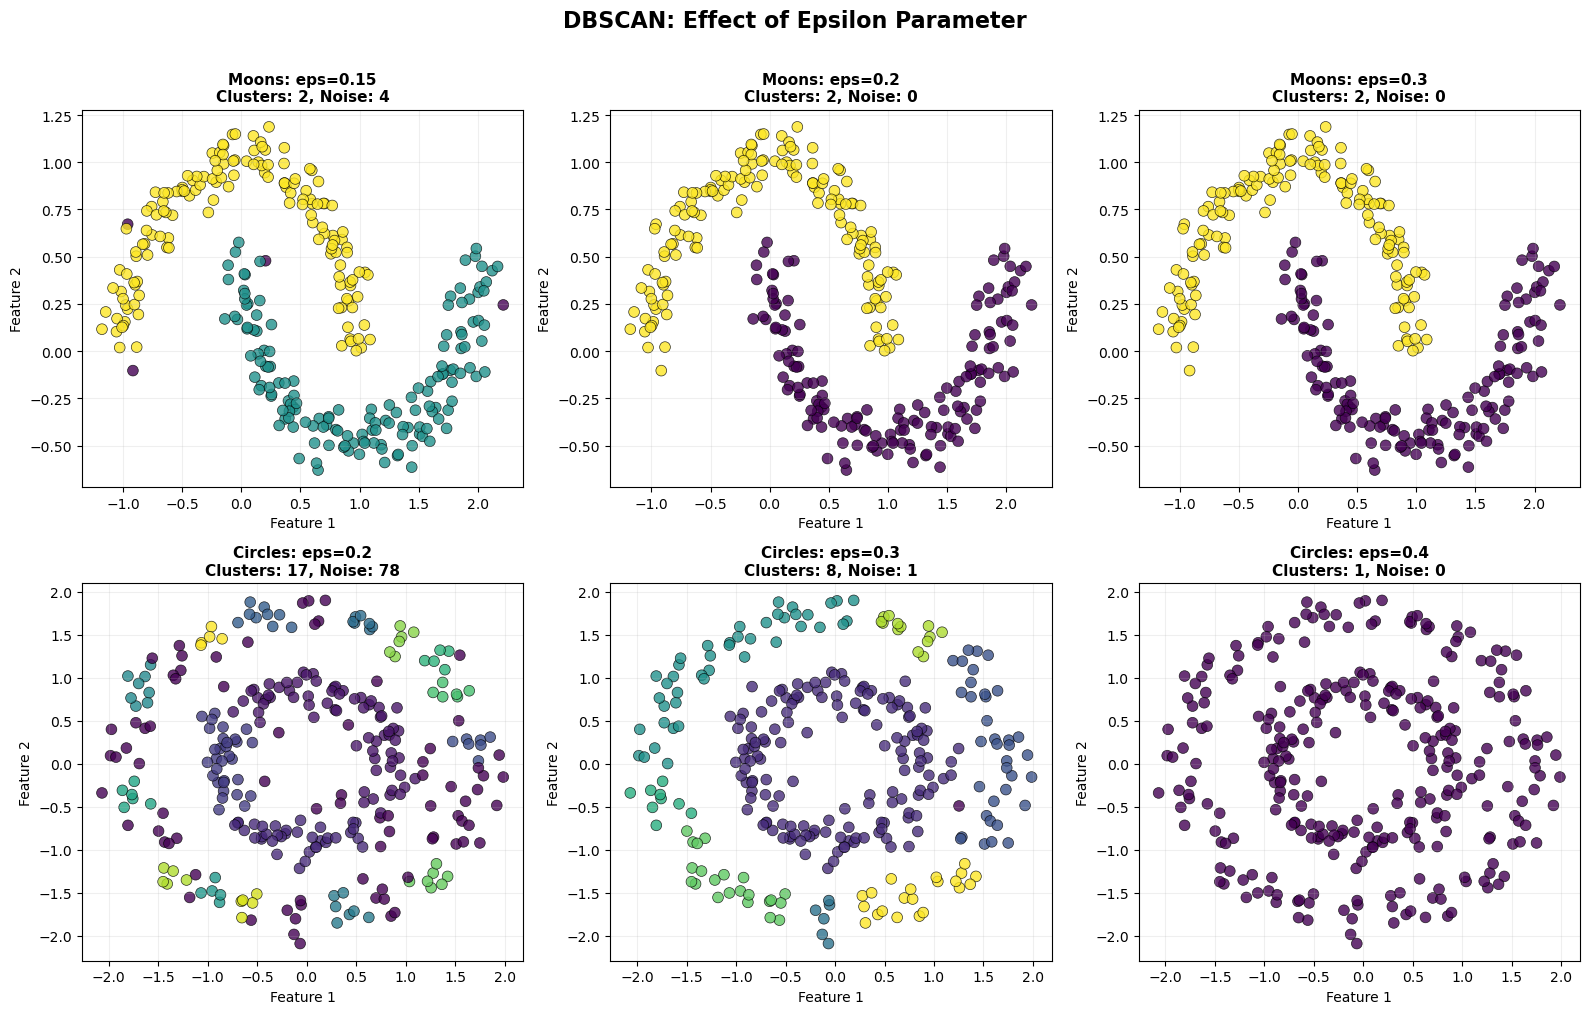

In [14]:
# Generate non-convex datasets
X_moons, _ = make_moons(n_samples=300, noise=0.08, random_state=42)
X_circles, _ = make_circles(n_samples=300, factor=0.5, noise=0.08, random_state=42)
X_circles = StandardScaler().fit_transform(X_circles)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: Moons with different eps
moon_eps_values = [0.15, 0.2, 0.3]
for idx, eps in enumerate(moon_eps_values):
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_moons)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    axes[0, idx].scatter(X_moons[:, 0], X_moons[:, 1], c=labels, cmap="viridis", 
                         s=60, alpha=0.8, edgecolors="k", linewidth=0.5)
    axes[0, idx].set_title("Moons: eps=" + str(eps) + "\nClusters: " + str(n_clusters) + 
                           ", Noise: " + str(n_noise), fontsize=11, fontweight="bold")
    axes[0, idx].set_xlabel("Feature 1")
    axes[0, idx].set_ylabel("Feature 2")
    axes[0, idx].grid(True, alpha=0.2)

# Row 2: Circles with different eps
circle_eps_values = [0.2, 0.3, 0.4]
for idx, eps in enumerate(circle_eps_values):
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_circles)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    axes[1, idx].scatter(X_circles[:, 0], X_circles[:, 1], c=labels, cmap="viridis", 
                         s=60, alpha=0.8, edgecolors="k", linewidth=0.5)
    axes[1, idx].set_title("Circles: eps=" + str(eps) + "\nClusters: " + str(n_clusters) + 
                           ", Noise: " + str(n_noise), fontsize=11, fontweight="bold")
    axes[1, idx].set_xlabel("Feature 1")
    axes[1, idx].set_ylabel("Feature 2")
    axes[1, idx].grid(True, alpha=0.2)

plt.suptitle("DBSCAN: Effect of Epsilon Parameter", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


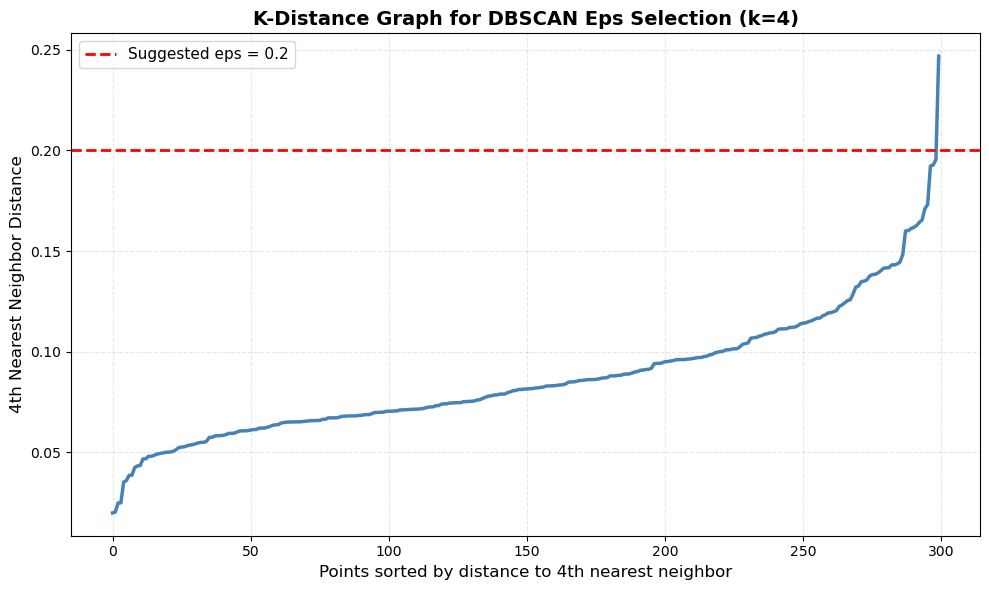

In [15]:
# K-Distance Graph for Eps Selection
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X_moons)
distances, indices = neighbors_fit.kneighbors(X_moons)
distances = np.sort(distances[:, 3], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(distances, linewidth=2.5, color="steelblue")
ax.set_title("K-Distance Graph for DBSCAN Eps Selection (k=4)", fontsize=14, fontweight="bold")
ax.set_xlabel("Points sorted by distance to 4th nearest neighbor", fontsize=12)
ax.set_ylabel("4th Nearest Neighbor Distance", fontsize=12)
ax.axhline(y=0.2, color="red", linestyle="--", linewidth=2, label="Suggested eps = 0.2")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()


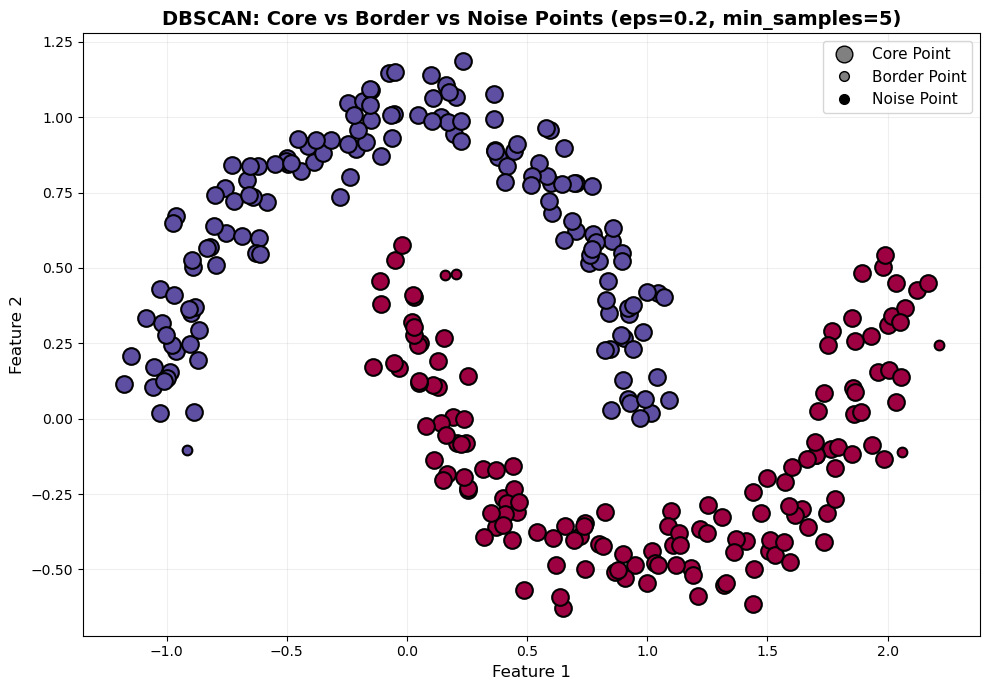

In [16]:
# DBSCAN: Core, Border, and Noise Points Visualization
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan.fit(X_moons)

core_samples_mask = np.zeros_like(dbscan.labels_, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True
labels = dbscan.labels_

fig, ax = plt.subplots(figsize=(10, 7))

unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # Black for noise
    
    class_member_mask = (labels == k)
    
    # Core points (larger markers)
    xy_core = X_moons[class_member_mask & core_samples_mask]
    ax.plot(xy_core[:, 0], xy_core[:, 1], "o", markerfacecolor=tuple(col), 
            markeredgecolor="k", markersize=12, markeredgewidth=1.5)
    
    # Border points (smaller markers)
    xy_border = X_moons[class_member_mask & ~core_samples_mask]
    ax.plot(xy_border[:, 0], xy_border[:, 1], "o", markerfacecolor=tuple(col), 
            markeredgecolor="k", markersize=7, markeredgewidth=1.5)

ax.set_title("DBSCAN: Core vs Border vs Noise Points (eps=0.2, min_samples=5)", 
             fontsize=14, fontweight="bold")
ax.set_xlabel("Feature 1", fontsize=12)
ax.set_ylabel("Feature 2", fontsize=12)

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", 
           markeredgecolor="k", markersize=12, label="Core Point"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", 
           markeredgecolor="k", markersize=7, label="Border Point"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="black", 
           markeredgecolor="k", markersize=7, label="Noise Point")
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


# 4. Hierarchical Clustering

## Theory

**Hierarchical Clustering** builds a tree of clusters (dendrogram) either:
- **Agglomerative (Bottom-Up)**: Each point starts as its own cluster; pairs of clusters are merged as we move up the hierarchy.
- **Divisive (Top-Down)**: All points start in one cluster; splits are performed recursively.

We focus on **Agglomerative Clustering** as it is more common.

### Linkage Criteria (how to measure distance between clusters):
- **Single Linkage**: Minimum distance between any two points in the two clusters
- **Complete Linkage**: Maximum distance between any two points in the two clusters
- **Average Linkage**: Average distance between all pairs of points in the two clusters
- **Ward Linkage**: Minimizes the variance within clusters (most common)

### Pros:
- No need to specify `k` beforehand (can be chosen by cutting the dendrogram)
- Produces an interpretable tree structure
- Works with any distance metric

### Cons:
- Computationally expensive: O(n^3) or O(n^2 log n) depending on implementation
- Sensitive to noise and outliers
- Cannot undo previous merges

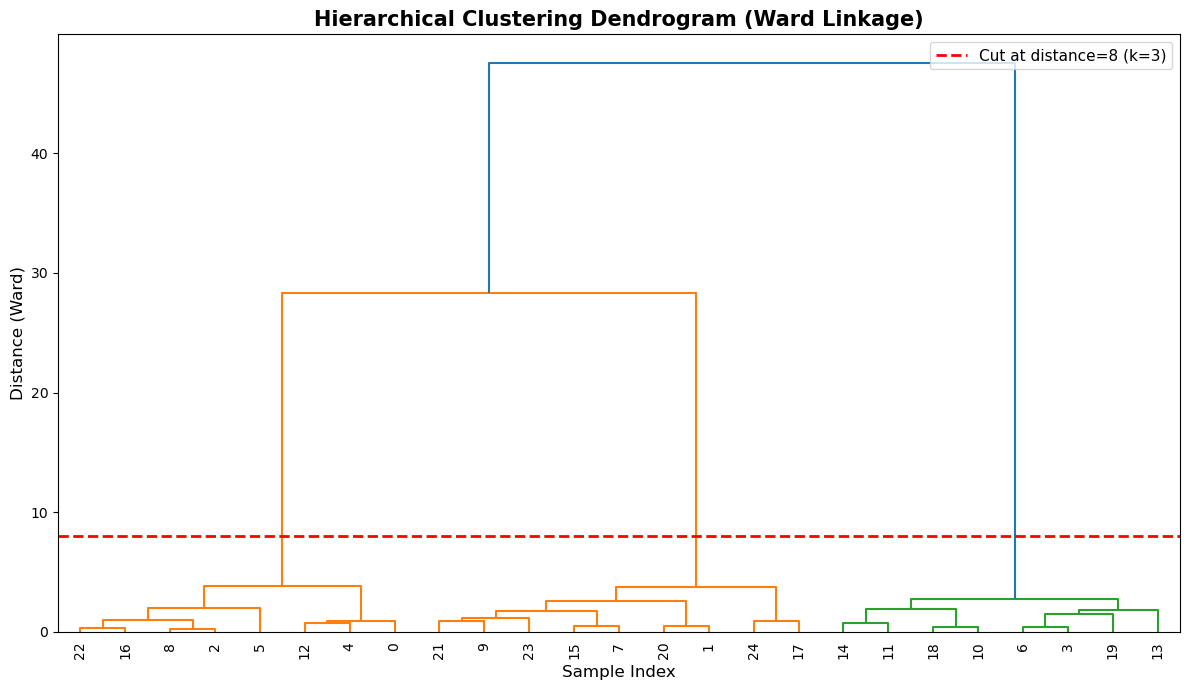

In [17]:
# Generate small dataset for clear dendrogram visualization
X_hier, _ = make_blobs(n_samples=25, centers=3, cluster_std=0.9, random_state=42)

# Dendrogram with Ward linkage
fig, ax = plt.subplots(figsize=(12, 7))
linked = linkage(X_hier, method="ward")
dendrogram(linked, orientation="top", distance_sort="descending", 
           show_leaf_counts=True, leaf_rotation=90., leaf_font_size=10, ax=ax)
ax.set_title("Hierarchical Clustering Dendrogram (Ward Linkage)", fontsize=15, fontweight="bold")
ax.set_xlabel("Sample Index", fontsize=12)
ax.set_ylabel("Distance (Ward)", fontsize=12)
ax.axhline(y=8, color="red", linestyle="--", linewidth=2, label="Cut at distance=8 (k=3)")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


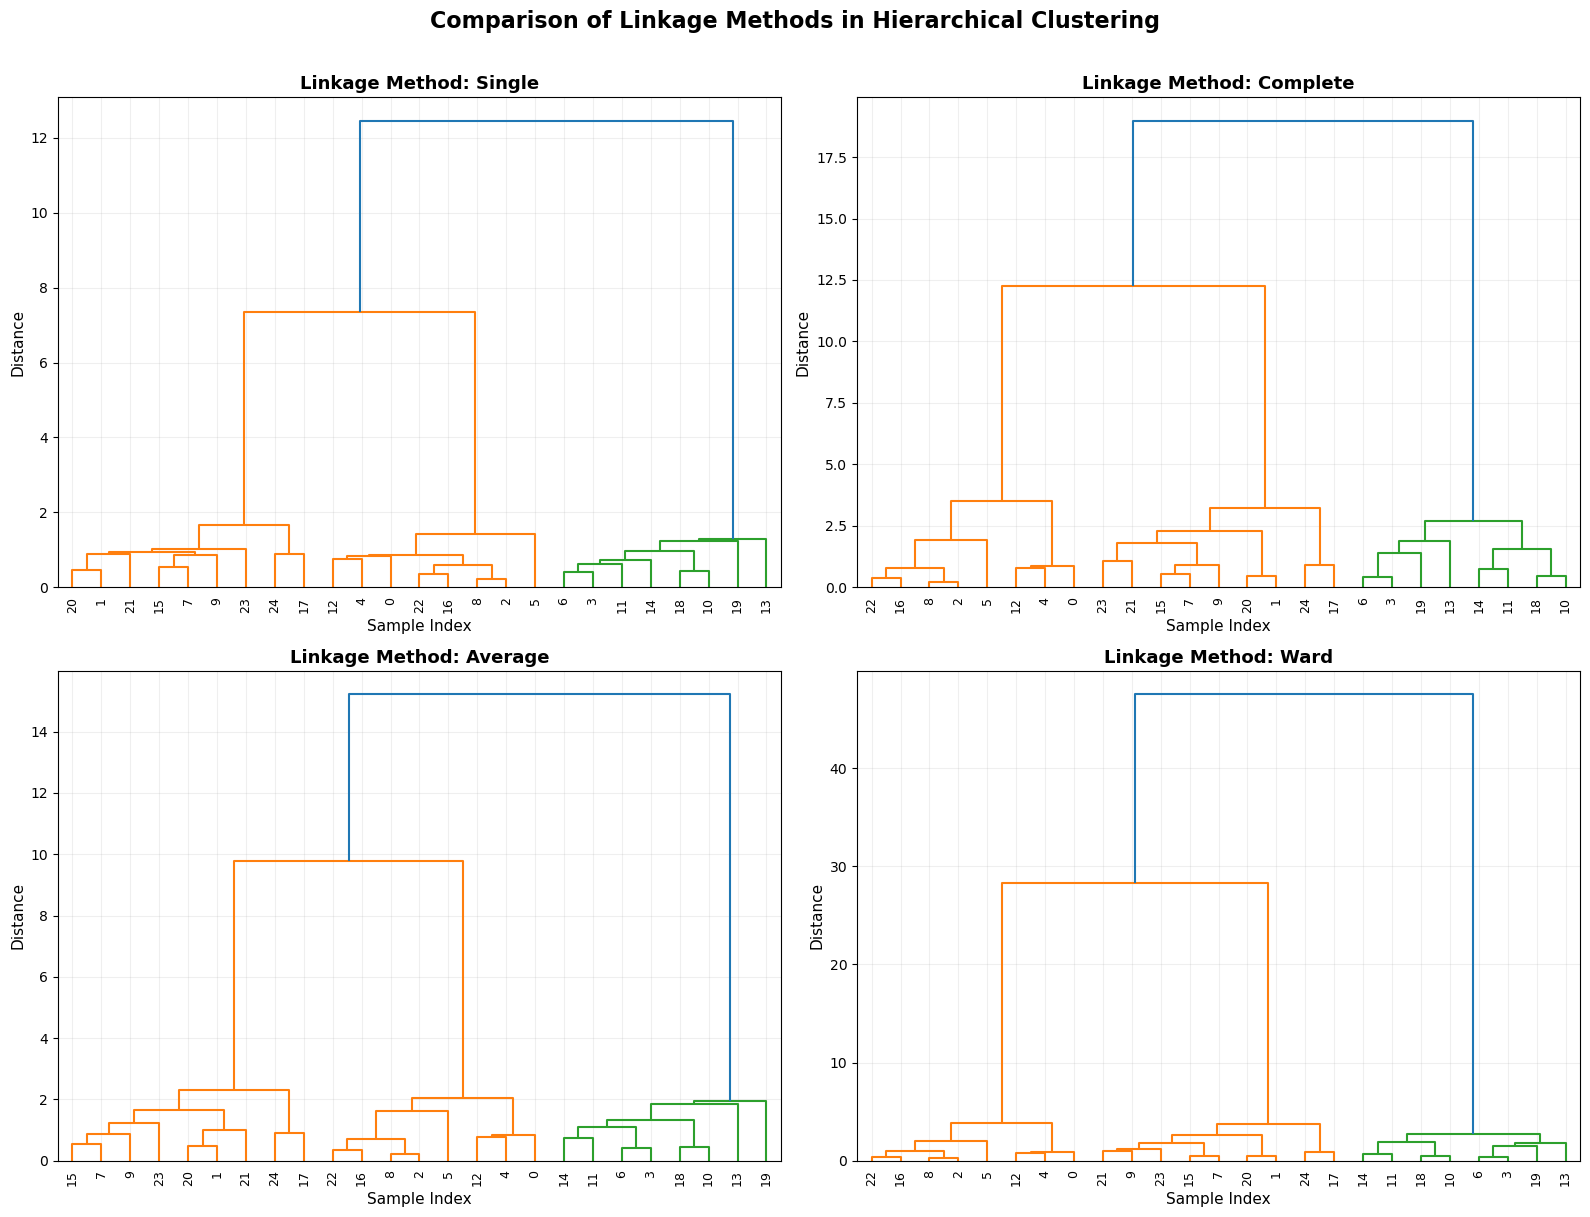

In [18]:
# Compare Different Linkage Methods
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
methods = ["single", "complete", "average", "ward"]

for ax, method in zip(axes.flat, methods):
    linked = linkage(X_hier, method=method)
    dendrogram(linked, ax=ax, leaf_rotation=90., leaf_font_size=9, 
               distance_sort="descending")
    ax.set_title("Linkage Method: " + method.capitalize(), fontsize=13, fontweight="bold")
    ax.set_xlabel("Sample Index", fontsize=11)
    ax.set_ylabel("Distance", fontsize=11)
    ax.grid(True, alpha=0.2)

plt.suptitle("Comparison of Linkage Methods in Hierarchical Clustering", 
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


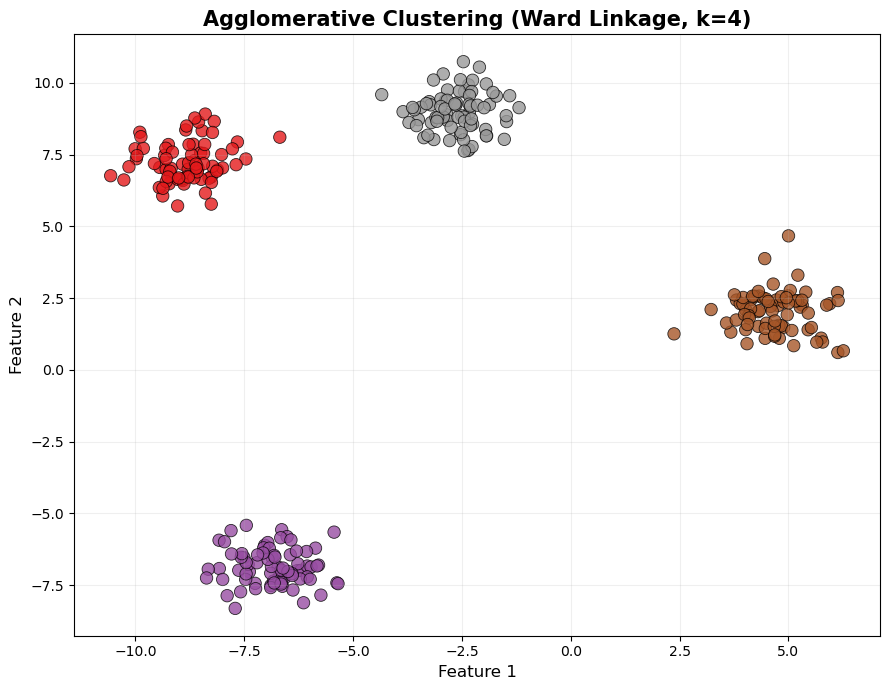

In [19]:
# Agglomerative Clustering Assignment on larger dataset
X_hier_large, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.7, random_state=42)

agg = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg.fit_predict(X_hier_large)

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    X_hier_large[:, 0], X_hier_large[:, 1], 
    c=labels_agg, cmap="Set1", s=80, alpha=0.8, 
    edgecolors="k", linewidth=0.6
)
ax.set_title("Agglomerative Clustering (Ward Linkage, k=4)", fontsize=15, fontweight="bold")
ax.set_xlabel("Feature 1", fontsize=12)
ax.set_ylabel("Feature 2", fontsize=12)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


# 5. Algorithm Comparison

Let's compare all three algorithms on the same **non-convex dataset** (moons) to highlight their strengths and weaknesses.


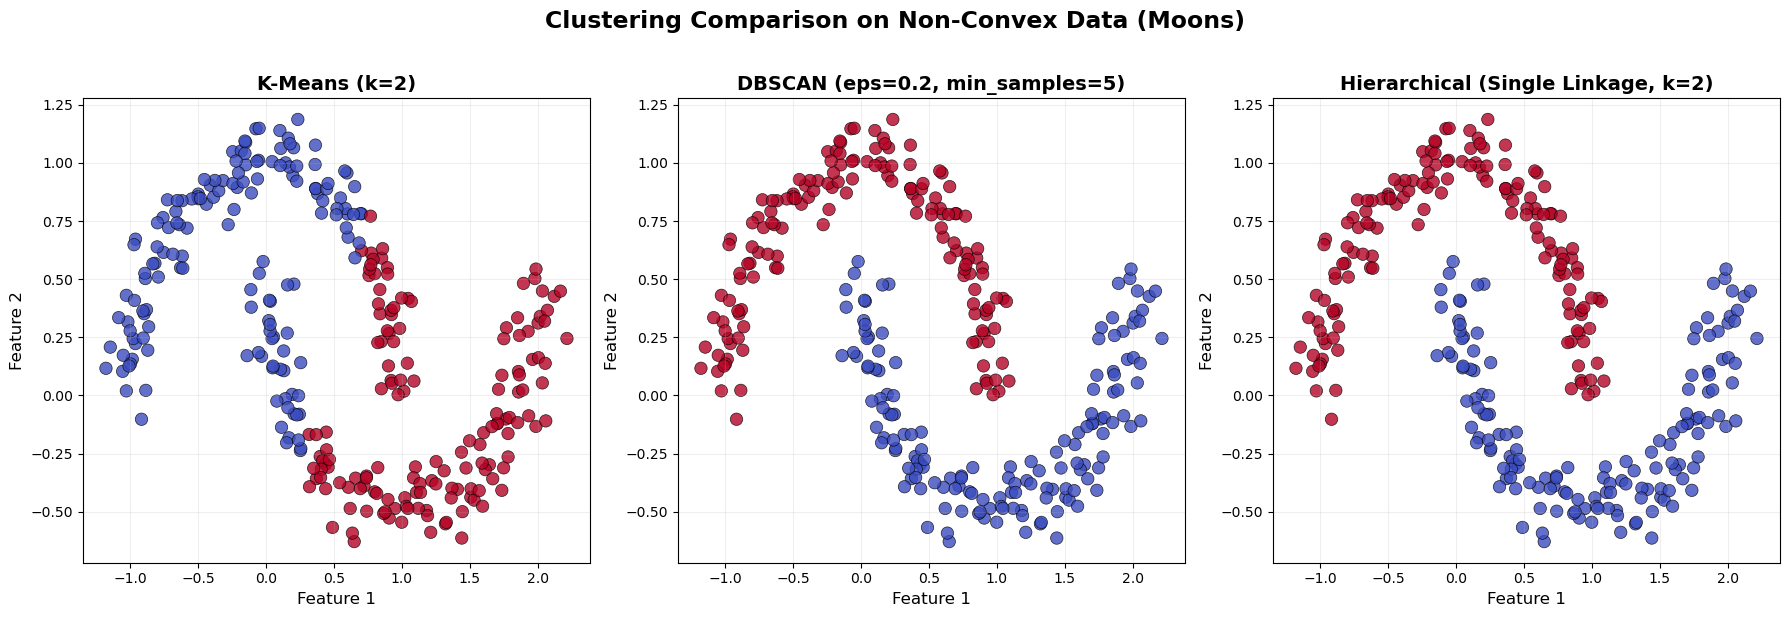

In [20]:
# Comparison on non-convex data (moons)
X_compare, _ = make_moons(n_samples=300, noise=0.08, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# K-Means
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_compare)
axes[0].scatter(X_compare[:, 0], X_compare[:, 1], c=labels_km, cmap="coolwarm", 
                s=80, alpha=0.8, edgecolors="k", linewidth=0.5)
axes[0].set_title("K-Means (k=2)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Feature 1", fontsize=12)
axes[0].set_ylabel("Feature 2", fontsize=12)
axes[0].grid(True, alpha=0.2)

# DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels_db = dbscan.fit_predict(X_compare)
axes[1].scatter(X_compare[:, 0], X_compare[:, 1], c=labels_db, cmap="coolwarm", 
                s=80, alpha=0.8, edgecolors="k", linewidth=0.5)
axes[1].set_title("DBSCAN (eps=0.2, min_samples=5)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Feature 1", fontsize=12)
axes[1].set_ylabel("Feature 2", fontsize=12)
axes[1].grid(True, alpha=0.2)

# Hierarchical (Single linkage works best for moons)
agg = AgglomerativeClustering(n_clusters=2, linkage="single")
labels_agg = agg.fit_predict(X_compare)
axes[2].scatter(X_compare[:, 0], X_compare[:, 1], c=labels_agg, cmap="coolwarm", 
                s=80, alpha=0.8, edgecolors="k", linewidth=0.5)
axes[2].set_title("Hierarchical (Single Linkage, k=2)", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Feature 1", fontsize=12)
axes[2].set_ylabel("Feature 2", fontsize=12)
axes[2].grid(True, alpha=0.2)

plt.suptitle("Clustering Comparison on Non-Convex Data (Moons)", 
             fontsize=17, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


---
# 6. Summary: When to Use Which Algorithm?

| Algorithm | Best For | Avoid When | Key Parameter |
|-----------|----------|------------|---------------|
| **K-Means** | Large datasets, spherical clusters, need speed | Non-convex shapes, varying densities, outliers | `k` (number of clusters) |
| **DBSCAN** | Arbitrary shapes, noise detection, unknown k | Varying densities, high-dimensional data | `eps`, `min_samples` |
| **Hierarchical** | Small datasets, interpretability needed, dendrogram | Large datasets (scalability), noise | `k`, linkage method |

## Practical Tips:
1. **Always scale your data** before clustering (StandardScaler or MinMaxScaler)
2. **Start with K-Means** for a baseline; it is fast and often good enough
3. **Use DBSCAN** when you suspect noise/outliers or non-convex shapes
4. **Use Hierarchical** when you need to understand cluster relationships or have a small dataset
5. **Combine methods**: Use hierarchical clustering on a sample to find `k`, then apply K-Means on the full dataset
6. **Validate visually** and with metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz)